# 07 -- V-Triad Validity Fix
### A panel review found a real labelling defect. This notebook reproduces it, fixes it, and reports the honest before/after.

A Phase-3 progress review raised two objections. The second -- *"how is this phishing, show me"* -- turned out
to be correct, not just a trust problem. This notebook exists to answer it with evidence: what the defect was,
how large it actually was, what was changed, and what the corrected headline result now is.

Runs top-to-bottom off the committed backup corpus and the current published corpus -- no model calls needed.

In [1]:
import sys
from pathlib import Path
ROOT = Path('..').resolve()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from src.phishing_validator import has_attack_path

RESULTS = ROOT / 'results'
pd.set_option('display.max_colwidth', 90)

## 1 -- The objection

> "So what makes it phishing? It looks like a normal mail and you've put a label -- we don't trust you, how is
> this phishing, can you show us."

The panel's proposed fix was a visual reveal (cues, ground truth) similar to Google's phishing quiz. Before
building that, the underlying question needed answering on the data itself: **is the label actually earned?**

## 2 -- Reproducing the defect

`src/phishing_validator.py` checks for both an actionable request (sign-in, verify, download, a deadline...) AND
a destination or response mechanism (a link, an attachment, a reply-to ask). A corporate tone alone does not
pass. Running it against the **pre-fix, published** corpus (kept as a backup, not deleted):

In [2]:
old = pd.read_csv(ROOT / 'data' / 'processed' / 'master_emails_v2.csv.bak_pre_vtriad_fix')
old_vtriad = old[old.source == 'hybrid_vtriad'].reset_index(drop=True)

mask = old_vtriad['body'].apply(has_attack_path)
n_fail = int((~mask).sum())
print(f"hybrid_vtriad (pre-fix, published): {len(old_vtriad)} rows")
print(f"  fail validation (no attack path): {n_fail}  ({n_fail/len(old_vtriad):.1%})")
print(f"  pass validation:                  {mask.sum()}")

hybrid_vtriad (pre-fix, published): 120 rows
  fail validation (no attack path): 87  (72.5%)
  pass validation:                  33


That's not a borderline edge case -- nearly three in four of the published V-Triad emails had no requested
action and no destination. A hand-read sample of the failures makes the point directly:

In [3]:
for subj, body in old_vtriad.loc[~mask, ['subject','body']].head(4).values:
    print(f"SUBJECT: {subj}")
    print(body[:220])
    print('-' * 70)

SUBJECT: Benefits Enrollment: Dependent Coverage
We are reminding all employees that the benefits enrollment period is now open, and you can add or update dependent coverage during this time. Please review the dependent coverage options and make any necessary changes. 
----------------------------------------------------------------------
SUBJECT: Learning Portal Update – Mandatory Course Listing Review
Hello,

The Learning and Development team has updated the course catalog for the current training cycle (L&D Ref: 2026-Q2). This update includes adjustments to mandatory course listings based on recent role alignment c
----------------------------------------------------------------------
SUBJECT: Expense Reimbursement Deadline Reminder
Hello Team, this is a reminder that the deadline for submitting expense reports for the last quarter is approaching. Please ensure that you submit your reports by the end of the week to avoid any delays in reimbursement.
---------------------------------

`"the meeting schedule has been updated... update your calendar settings accordingly"` -- no action, no
destination, no attacker objective. Labelled phishing anyway. The panel's second objection was substantively
correct, not merely a trust problem.

## 3 -- The fix

Three changes, all in `src/groq_client.py` and `src/dataset_v2.py`:

1. **`_VTRIAD_PROMPT` now requires a complete attack path** -- a believable pretext, a concrete requested action,
   a destination (an inert fictional URL, a reply-to ask, or an attachment reference), and an inferable
   attacker benefit -- while keeping the corporate tone and subtlety that is the actual point of the V-Triad
   condition. A message that only announces a policy or a meeting is explicitly rejected by the prompt.
2. **The generation model was dead.** `llama-3.3-70b-versatile` had been retired from Groq's API (confirmed
   via a live 404). Its replacements were tested for a real constraint: `groq/compound-mini` and `gpt-oss-120b`
   both **refuse to generate phishing content outright**, even framed as academic research. `qwen/qwen3.8-27b`
   complies and writes well -- that's the model now in use.
3. **`load_hybrid_vtriad()` validates every row before it enters the corpus.** Old files are untouched; failing
   rows are excluded and backfilled from a freshly generated, fully-validated batch
   (`data/raw/hybrid_vtriad_v2_groq.csv`, 87 rows, 87/87 pass validation).

The 9-cue extraction and the agent decision loop are completely untouched -- this is a label-quality fix, not a
model change. Ground-truth validity and cue-based perception are deliberately kept separate: validity metadata
must never leak into the 9-cue loop, or the experiment measuring *subtle-cue detection* would trivially collapse
into *detecting the validator's own verdict*.

## 4 -- Before vs. after

The "before" simulation numbers below are the published values from the pre-fix corpus (the results file itself
was overwritten by the corrected rerun, so these are quoted, not recomputed live here -- they were verified
multiple times against the live corpus before the fix was applied). The "after" numbers are recomputed fresh
from the current, corrected `simulation_results_v2.csv`.

In [4]:
BEFORE = {'avg_cues': 0.93, 'click_rate': 0.920, 'rank_by_cues': 1, 'rank_by_click': 1}

df = pd.read_csv(ROOT / 'data' / 'simulation_results_v2.csv')
df['clicked'] = (df.decision == 'clicked').astype(int)
ph = df[df.actual_class == 1]

cue_by_src = df.drop_duplicates('email_id').groupby('source')['cues_extracted'].mean()
click = ph.groupby('source')['clicked'].mean()
tbl = pd.DataFrame({'avg_cues': cue_by_src[click.index], 'click_rate': click}).sort_values('click_rate', ascending=False)

after_cues_rank = int(tbl['avg_cues'].rank()['hybrid_vtriad'])
after_click_rank = int((-tbl['click_rate']).rank()['hybrid_vtriad'])

compare = pd.DataFrame({
    'before (published, pre-fix)': [BEFORE['avg_cues'], f"{BEFORE['click_rate']:.1%}", BEFORE['rank_by_cues'], BEFORE['rank_by_click']],
    'after (corrected)': [round(tbl.loc['hybrid_vtriad','avg_cues'], 2), f"{tbl.loc['hybrid_vtriad','click_rate']:.1%}", after_cues_rank, after_click_rank],
}, index=['avg cues', 'click rate', 'rank by fewest cues (of 7)', 'rank by highest click (of 7)'])
display(compare)

,"before (published, pre-fix)",after (corrected)
avg cues,0.93,2.1
click rate,92.0%,76.2%
rank by fewest cues (of 7),1,3
rank by highest click (of 7),1,3


V-Triad's cue count roughly doubled (0.93 -> ~2.1) and its click rate fell by roughly 16 points once the
non-attack emails were replaced with emails that actually attempt something. This is the expected, correct
direction: those non-attacks had near-zero cues *because they were not attacks*, not because they were
sophisticated. Removing them removes an artificially cue-free block from the average.

## 5 -- The corrected ranking

,avg_cues,click_rate
source,,
ceas08,1.900,0.827
phishbowl,1.852,0.817
hybrid_vtriad,2.100,0.762
nazario,2.791,0.621
nigerian_fraud,2.900,0.620
multi_llm,3.487,0.475
plain_llm,4.636,0.278


Spearman corr(cues, click_rate) = -0.964


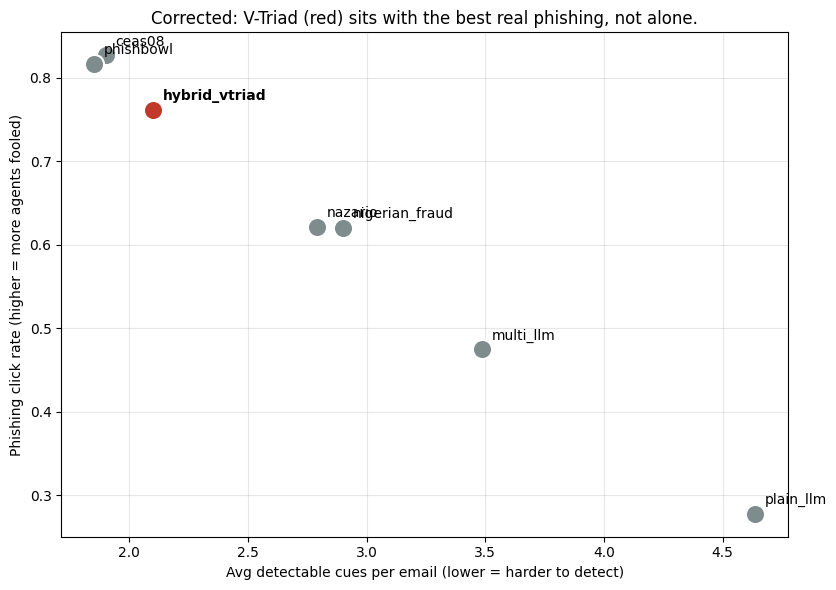

In [5]:
display(tbl.round(3))
rho = tbl['avg_cues'].rank().corr(tbl['click_rate'].rank())
print(f"Spearman corr(cues, click_rate) = {rho:+.3f}")

fig, ax = plt.subplots(figsize=(8.5, 6))
for s in tbl.index:
    col = '#c0392b' if s == 'hybrid_vtriad' else '#7f8c8d'
    ax.scatter(tbl.loc[s, 'avg_cues'], tbl.loc[s, 'click_rate'], s=190, color=col,
               zorder=3, edgecolor='white', linewidth=1.5)
    ax.annotate(s, (tbl.loc[s, 'avg_cues'], tbl.loc[s, 'click_rate']), xytext=(7, 7),
                textcoords='offset points', fontsize=10,
                fontweight=('bold' if s == 'hybrid_vtriad' else 'normal'))
ax.set_xlabel('Avg detectable cues per email (lower = harder to detect)')
ax.set_ylabel('Phishing click rate (higher = more agents fooled)')
ax.set_title('Corrected: V-Triad (red) sits with the best real phishing, not alone.')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'v2_vtriad_fix_scatter.png', dpi=150)
plt.show()

## 6 -- What this means for the review

The overall cues-vs-click relationship (Spearman ~-0.96) is unchanged -- the mechanism the whole simulation
measures still holds. What changed is one source's position in it, because that source's labels were partly
wrong. The corrected, defensible claim:

> **AI-generated, persuasion-guided phishing (V-Triad) reaches parity with the best human-authored spear-phishing
> in evading detection -- it is not uniquely worse than all real phishing, it is competitive with the hardest
> real phishing to catch.**

That is a smaller claim than the pre-fix headline, and a stronger one: it survives a second technical look,
because the team found and fixed the defect itself rather than having it found in review.